In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt


In [149]:
def import_and_combine_csv(files):
    dataframes = []
    for file in files:
        df = pd.read_csv(file)
        #Extract city name from before the .csv 
        city_name = file.split('/')[-1].split('.')[0]  
        df['city'] = city_name
        dataframes.append(df)
    combined_df = pd.concat(dataframes, ignore_index=True)
    return combined_df

files = ['./clean_monthly_average_data/amsterdam.csv', './clean_monthly_average_data/brussels.csv', './clean_monthly_average_data/helsinki.csv', './clean_monthly_average_data/london.csv', './clean_monthly_average_data/paris.csv']
combined_data = import_and_combine_csv(files)

In [150]:
combined_data.head()

,date,pm25,pm10,o3,no2,city
0,2013-12-31,56.13,24.85,26.47,30.00,amsterdam
1,2014-01-31,56.13,25.33,24.64,32.37,amsterdam
2,2014-02-28,56.13,21.43,18.07,28.21,amsterdam
3,2014-03-31,56.13,36.42,20.97,32.39,amsterdam
4,2014-04-30,56.13,38.50,23.40,30.60,amsterdam


In [151]:
def calculate_error_rate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = sqrt(mse)
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    return mae, mse, rmse

In [152]:
def forecast_error(data, city, pollutant, test_size=20):
    # Filter data for the specified city and pollutant
    city_data = data[(data['city'] == city)]
    prophet_df = city_data[['date', pollutant]].dropna().rename(columns={'date': 'ds', pollutant: 'y'})
    prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])
    prophet_df = prophet_df.set_index('ds').asfreq('M').reset_index()
    #print(city_data.head())

    train_df=prophet_df[:-test_size]
    test_df=prophet_df[-test_size:]

    # Initialize and fit the Prophet model
    m = Prophet()
    m.fit(train_df)

    # Create a future DataFrame for forecasting
    future_periods = (test_df['ds'].max() - train_df['ds'].max()).days // 30 + 1
    future = m.make_future_dataframe(periods=future_periods, freq='M') 

    # Forecast
    forecast = m.predict(future)

    #Error calculation 
    forecasted_test = forecast[-test_size:]
    y_true = test_df['y'].values
    y_pred = forecasted_test['yhat'][-test_size:].values
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = sqrt(mse)

    print(f"Mean Absolute Error (MAE): {mae}")
    print(f"Mean Squared Error (MSE): {mse}")
    print(f"Root Mean Squared Error (RMSE): {rmse}")
    # Plot the historical and forecasted data
    plt.figure(figsize=(10, 6))
    plt.plot(train_df['ds'], train_df['y'], label='Historical', color='blue')
    plt.plot(test_df['ds'], y_true, label='Actual', color='green')
    plt.plot(forecasted_test['ds'], y_pred, label='Forecast', color='red', linestyle='--')

    # We only plot the 'yhat' values for the forecasted dates, not the historical dates
    forecasted = forecast[forecast['ds'] > prophet_df['ds'].max()]

    plt.xlabel('Date')
    plt.ylabel(f'{pollutant} Level')
    plt.title(f'Historical and Forecasted {pollutant} Levels in {city}')
    plt.legend()
    plt.show()

    return forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

14:00:44 - cmdstanpy - INFO - Chain [1] start processing


14:00:44 - cmdstanpy - INFO - Chain [1] done processing


Mean Absolute Error (MAE): 3.762971416115261
Mean Squared Error (MSE): 28.31083459057025
Root Mean Squared Error (RMSE): 5.320792665625137


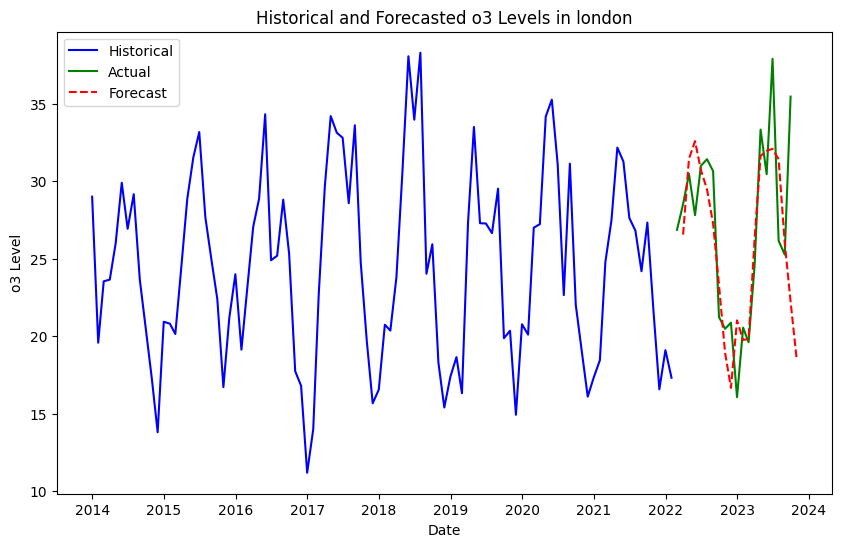

In [161]:
#Main Pollutant forecaster

values=forecast_error(combined_data, 'london', 'o3')

In [158]:
def forecast_pollutant_future(data, city, pollutant, target_year=None, target_month=None):
    # Filter data for the specified city and pollutant
    city_data = data[(data['city'] == city)]
    prophet_df = city_data[['date', pollutant]].dropna().rename(columns={'date': 'ds', pollutant: 'y'})
    prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])
    prophet_df = prophet_df.set_index('ds').asfreq('M').reset_index()

    # Initialize and fit the Prophet model
    m = Prophet()
    m.fit(prophet_df)

    # Create a future DataFrame for forecasting
    future = m.make_future_dataframe(periods=60, freq='M') 

    # Forecast
    forecast = m.predict(future)

    # Plot the historical and forecasted data
    plt.figure(figsize=(10, 6))
    plt.plot(prophet_df['ds'], prophet_df['y'], label='Historical', color='blue')

    # We only plot the 'yhat' values for the forecasted dates, not the historical dates
    forecasted = forecast[forecast['ds'] > prophet_df['ds'].max()]
    plt.plot(forecasted['ds'], forecasted['yhat'], label='Forecast', color='red', linestyle='--')
    plt.plot(forecasted['ds'], forecasted['yhat_lower'], label='Lower Bound', color='orange', linestyle='--')
    plt.plot(forecasted['ds'], forecasted['yhat_upper'], label='Upper Bound ', color='orange', linestyle='--')
    # Add labels and legend
    plt.xlabel('Date')
    plt.ylabel(f'{pollutant} Level')
    plt.title(f'Historical and Forecasted {pollutant} Levels in {city}')
    plt.legend()
    plt.show()

    # Plot the forecast components
    fig = m.plot_components(forecast)
    plt.show()

    # If a target year and month are provided, find the forecasted value for that period
    if target_year and target_month:
        forecasted_value_row = forecast[(forecast['ds'].dt.year == target_year) & (forecast['ds'].dt.month == target_month)]
        if not forecasted_value_row.empty:
            forecasted_value = forecasted_value_row['yhat'].iloc[0]
            print(f"The forecasted {pollutant} level for {city} in {target_month:02d}-{target_year} is {forecasted_value:.2f}")
        else:
            print(f"No forecast available for {target_month:02d}-{target_year} in {city}.")

    # Return the forecast DataFrame
    return forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

14:01:26 - cmdstanpy - INFO - Chain [1] start processing


14:01:26 - cmdstanpy - INFO - Chain [1] done processing


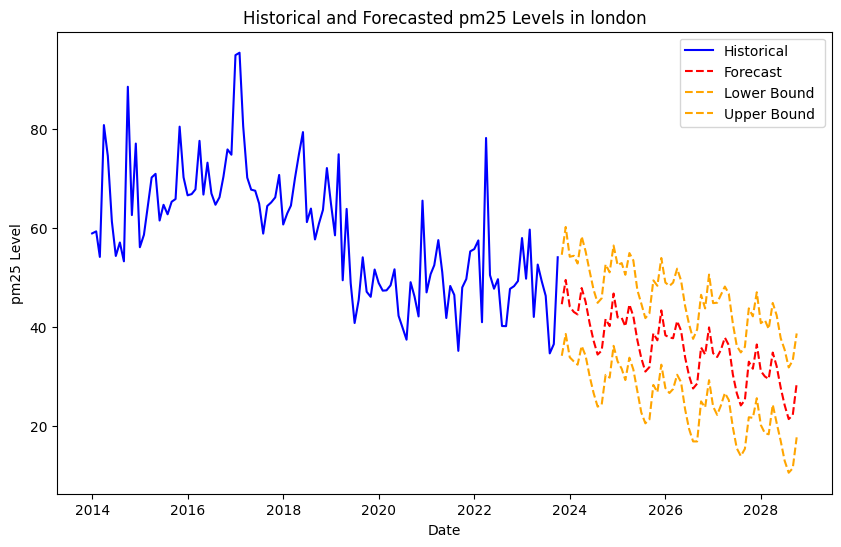

/Users/rheagupta/Documents/x6/.venv/lib/python3.11/site-packages/prophet/plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
/Users/rheagupta/Documents/x6/.venv/lib/python3.11/site-packages/prophet/plot.py:351: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  df_y['ds'].dt.to_pydatetime(), seas[name], ls='-', c='#0072B2')
/Users/rheagupta/Documents/x6/.venv/lib/python3.11/site-packages/prophet/plot.py:354: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime o

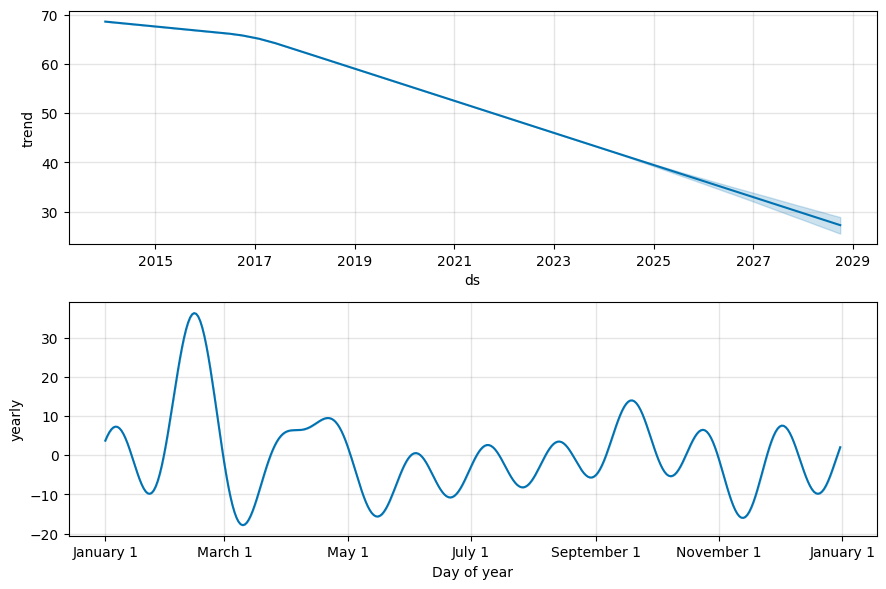

The forecasted pm25 level for london in 03-2028 is 34.82


,ds,yhat,yhat_lower,yhat_upper
0,2013-12-31,70.723140,60.918794,81.273659
1,2014-01-31,70.480923,59.909175,81.227889
2,2014-02-28,70.494692,60.381163,80.998336
3,2014-03-31,74.167820,64.247977,85.435100
4,2014-04-30,72.406768,61.551831,82.417038
...,...,...,...,...
173,2028-05-31,27.683051,16.904419,37.718271
174,2028-06-30,24.173480,12.914882,35.389234
175,2028-07-31,21.348837,10.488035,31.804405
176,2028-08-31,22.149370,11.400588,33.210138


In [163]:
forecast_pollutant_future(combined_data, 'london', 'pm25', target_year=2028, target_month=3)

15:57:55 - cmdstanpy - INFO - Chain [1] start processing
15:57:55 - cmdstanpy - INFO - Chain [1] done processing


Mean Absolute Error (MAE): 10.218462488994774
Mean Squared Error (MSE): 195.1614552828854
Root Mean Squared Error (RMSE): 13.970019874104883


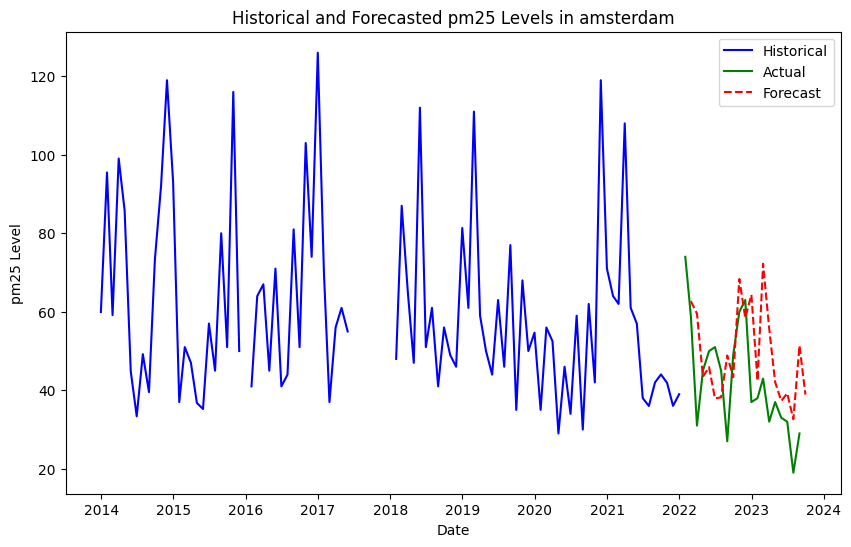

15:57:55 - cmdstanpy - INFO - Chain [1] start processing
15:57:55 - cmdstanpy - INFO - Chain [1] done processing


Mean Absolute Error (MAE): 6.015567262306758
Mean Squared Error (MSE): 57.20870851122406
Root Mean Squared Error (RMSE): 7.5636438646477835


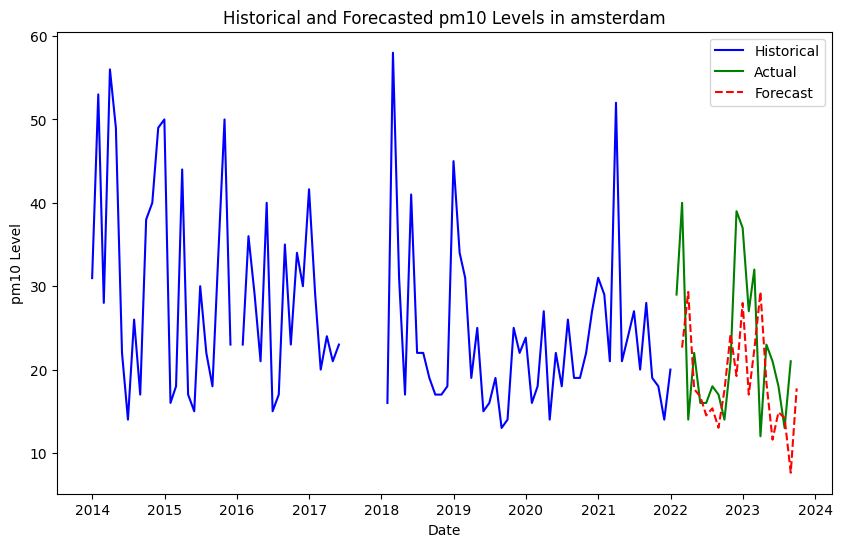

15:57:55 - cmdstanpy - INFO - Chain [1] start processing
15:57:55 - cmdstanpy - INFO - Chain [1] done processing


Mean Absolute Error (MAE): 6.687999121039647
Mean Squared Error (MSE): 68.85495786607189
Root Mean Squared Error (RMSE): 8.297888759562392


KeyboardInterrupt: 

In [144]:
#This gives all outputs for every city and pollutant combination

def run_forecasts(combined_data, cities, pollutants):
    forecasts = {}
    for city in cities:
        for pollutant in pollutants:
            key = (city, pollutant)
            forecasts[key] = forecast_pollutant(combined_data, city, pollutant)
    return forecasts

cities = ['amsterdam', 'brussels', 'helsinki', 'london', 'paris']
pollutants = ['pm25', 'pm10', 'o3', 'no2']
forecasts = run_forecasts(combined_data, cities, pollutants)
city_forecast = forecasts[('helsinki', 'no2')]
print(city_forecast.tail())